Анализ входных данных

In [330]:
import pandas as pd 
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import string
from collections import defaultdict
import re
from nltk.tokenize import word_tokenize

In [331]:
train_data_tkk = pd.read_csv('input_texts/tkk_train.csv')
test_data_tkk = pd.read_csv('input_texts/tkk_etalon.csv')
train_data_bank = pd.read_csv('input_texts/bank_train.csv')
test_data_bank = pd.read_csv('input_texts/bank_etalon.csv')
data_refs = {'bank_train': train_data_bank, 'bank_test': test_data_bank, 'tkk_train':train_data_tkk, 'tkk_test': test_data_tkk}



In [332]:
def _replace_email_with_token(text, token='[EMAIL]'):
    email_pattern = r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+'
    return re.sub(email_pattern, token, text)
    
def _replace_url_with_token(text, token='[URL]'):
    url_pattern = r'https?://\S+'
    return re.sub(url_pattern, token, text)
    
def _replace_mentions_with_token(text, token='[MENTION]'):
        mention_pattern = r'@\w+'
        return re.sub(mention_pattern, token, text)

def _replace_hashtags_with_token(text, token='[HASHTAG]'):
    hashtag_pattern = r'#\w+'
    return re.sub(hashtag_pattern, token, text)

def _replace_numbers_with_token(text, token='[NUMBER]'):
    number_pattern = r'\d+'
    return re.sub(number_pattern, token, text)

def _to_lower_case(text: str):
    return text.lower()

In [333]:
def plot_features_distr(df, graph_name, col_name = 'label'):
    
    plt.figure(figsize=(3, 2)) 
    sns.countplot(data=df, x= col_name, palette='Set2')
    plt.title(graph_name)
    plt.xlabel('Category')
    plt.ylabel(f'Number of texts')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(f'{graph_name}.png', bbox_inches='tight')
    plt.show()

Statistics for bank_train dataset.
Number of texts: 8535
total number of words in corpus: 112573
total number of symbols in corpus: 595743
Average words number in text: 13.189572349150556 
Vocabulary size 10758 



C:\Users\ThinkPad T15 Gen1\AppData\Local\Temp\ipykernel_26712\3769694708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col_name, palette='Set2')


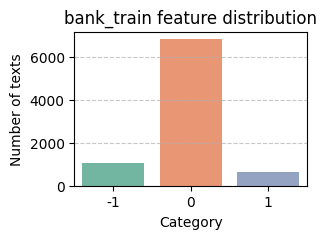

Statistics for bank_test dataset.
Number of texts: 3212
total number of words in corpus: 56749
total number of symbols in corpus: 302919
Average words number in text: 17.66780821917808 
Vocabulary size 8070 



C:\Users\ThinkPad T15 Gen1\AppData\Local\Temp\ipykernel_26712\3769694708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col_name, palette='Set2')


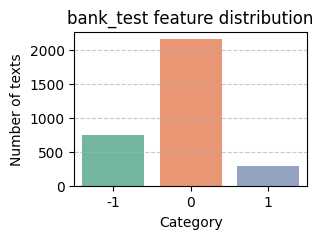

Statistics for tkk_train dataset.
Number of texts: 8208
total number of words in corpus: 146416
total number of symbols in corpus: 735533
Average words number in text: 17.83820662768031 
Vocabulary size 15103 



C:\Users\ThinkPad T15 Gen1\AppData\Local\Temp\ipykernel_26712\3769694708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col_name, palette='Set2')


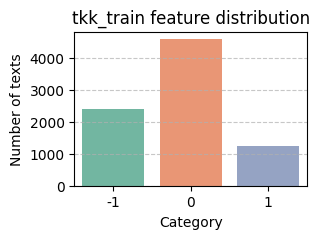

Statistics for tkk_test dataset.
Number of texts: 2054
total number of words in corpus: 42361
total number of symbols in corpus: 209748
Average words number in text: 20.623661148977604 
Vocabulary size 7158 



C:\Users\ThinkPad T15 Gen1\AppData\Local\Temp\ipykernel_26712\3769694708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col_name, palette='Set2')


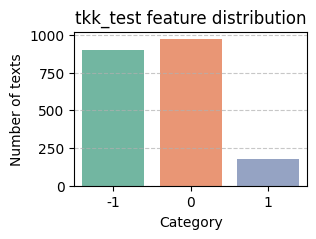

In [334]:
tqdm.pandas()
d = defaultdict()
for k, v in data_refs.items():
    print(f"Statistics for {k} dataset.")
    v['text'] = v['text'].apply(lambda x: _to_lower_case(x))
    v['text'] = v['text'].apply(lambda x: _replace_email_with_token(x))
    v['text'] = v['text'].apply(lambda x: _replace_url_with_token(x))
    v['text'] = v['text'].apply(lambda x: _replace_mentions_with_token(x))
    v['text'] = v['text'].apply(lambda x: _replace_hashtags_with_token(x))
    v['text'] = v['text'].apply(lambda x: _replace_numbers_with_token(x))
    v['text'] = v['text'].apply(word_tokenize)
    v['text'] = v['text'].str.join(' ')
    v['words_count'] = v['text'].fillna('').str.split().apply(len)
    v['symbols_count'] = v['text'].fillna('').str.len()
    #print(v.head())
    n_texts =  len(v['text'])
    n_words = v['words_count'].sum()
    mean_words = v['words_count'].mean()
    symbols = v['symbols_count'].sum()
    all_text = " ".join(v["text"].astype(str))
    all_text = all_text.lower()
    translator = str.maketrans('', '', string.punctuation)
    all_text = all_text.translate(translator)
    all_words = all_text.split()
    vocabulary = set(all_words)
    d[k] = vocabulary
    print(f'Number of texts: {n_texts}')
    print(f'total number of words in corpus: {n_words}')
    print(f'total number of symbols in corpus: {symbols}')
    print(f'Average words number in text: {mean_words} ')
    print(f"Vocabulary size {len(vocabulary)} \n")
    plot_features_distr(v, f"{k} feature distribution")


        

In [335]:
bank_vocab_delta =  d['bank_test'] - d['bank_train'] 
tkk_vocab_delta =  d['tkk_test'] - d['tkk_train'] 

#print(set(vocab_delta))
print(f'Out of bank vocab rate {len(bank_vocab_delta)/len(d['bank_test'])*100}')
print(f'Out of telecommunication vocab rate {len(tkk_vocab_delta)/len(d['tkk_test'])*100}')

Out of bank vocab rate 56.171003717472125
Out of telecommunication vocab rate 45.138306789606034


In [336]:
#print(len(d['bank_test']))
#print(len(d['bank_train']))
#print(len(vocab_delta))
#print(vocab_delta)

In [337]:
print(len(vocab_delta))

4784


Statistics for bank_train dataset.
Number of texts: 8535
total number of words in corpus: 78067
total number of symbols in corpus: 560953
Average words number in text: 9.146690099589923 
Vocabulary size 11142 